In [177]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from uncertainties import ufloat
from uncertainties import unumpy as unp

In [178]:
def theta(t, A, tau, w, phase, h):
        return A * np.exp(-t/tau) * np.sin(w*t + phase) + h

def lin(x,a,b):
        return a*x + b

def rotate_data(t, xdata, ydata):
    popt, pcov = curve_fit(lin, xdata=xdata, ydata=ydata)
    phi = np.arctan(popt[0])
    
    x = xdata * np.cos(-phi) - (ydata - popt[1]) * np.sin(-phi)
    y = xdata * np.sin(-phi) + (ydata - popt[1]) * np.cos(-phi)

    return x, y

def fit(t, xdata, ydata, p0: list = [180, 2000, 0.017, -1.5, 630], cutoff: int = 0):
    x, y = rotate_data(t, xdata, ydata)

    popt, pcov = curve_fit(theta, t[cutoff:], x[cutoff:], p0=p0)

    fig, (ax1, ax2) = plt.subplots(2, sharex=True)

    ax1.plot(t, x - popt[4], 'k.', ms=1)
    ax1.plot(t[cutoff:], theta(t[cutoff:], *popt) - popt[4], 'r')
    #ax1.set_xlabel('t')
    ax1.set_ylabel('x')

    ax2.errorbar(t, y, fmt='k.', capsize=1, linewidth=0.6, ms=0.8)
    ax2.set_xlabel('t')
    ax2.set_ylabel('y')

    #T = 2 * np.pi / ufloat(popt[2], pcov[2,2]**0.5)

    return unp.uarray(popt, np.sqrt(np.diag(pcov)))

In [179]:
# calculate G , incl uncertainties
def G(theta1, theta2, T, conversion_factor):
    #technical drawing
    m = unp.uarray(0.028, 0)  #0.028 #kg tech drawing
    l=unp.uarray(0.0429, 0.001) #uncert tech drawing
    I = m*l**2/2 #kg m^2, using MIT estimated formula
    
    # laser meas
    L =  unp.uarray(4.321, 0.001) #m
        
    #measured:
    M = unp.uarray(1.5,0.01)  #kg +/-10g
    
    r1 = unp.uarray(0.051722,0.00011) #m  51.722+/-0.011
    r2 = unp.uarray(0.052152,0.00011) #m  52.152+/-0.011
        
    #fit: T0, dtheta1, dtheta2
    h1=theta1*conversion_factor #conversion factor for vid setup 1 in cm/'m'. used squared addition here
    h2=theta2*conversion_factor
    
    #dtheta= unp.arctan( (theta2 - theta1)*0.01 / 4.321) #0.01 go from cm to m
    dtheta= 2*unp.arctan( (0.5*(h2 - h1))*0.01 / 4.321) #0.01 go from cm to m
    #T = unp.uarray(379.9587037978669, 0) # mean of both, in principle we have zero measurement for full glory
    
    #formula static deflection
    delta = 0.002 #m
    c1 = m*M*l/(r1)**2
    c2 = -m*M*l/(r2)**2 
    
    G = 4 * np.pi**2 * I / T**2 * (dtheta)/(c1 - c2)  #units kg m^2 /s^2  * m^2/kg^2/m
    
    return G

(1.66+/-0.04)e-10


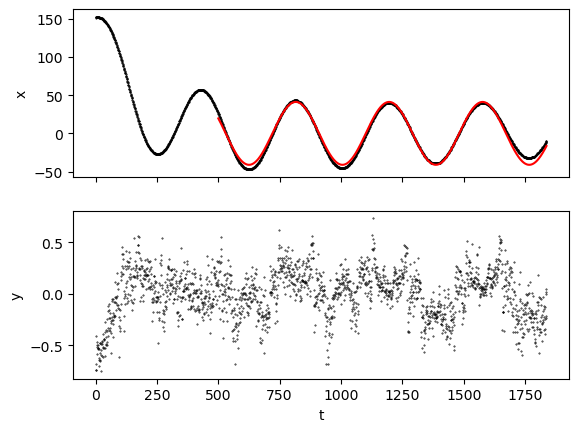

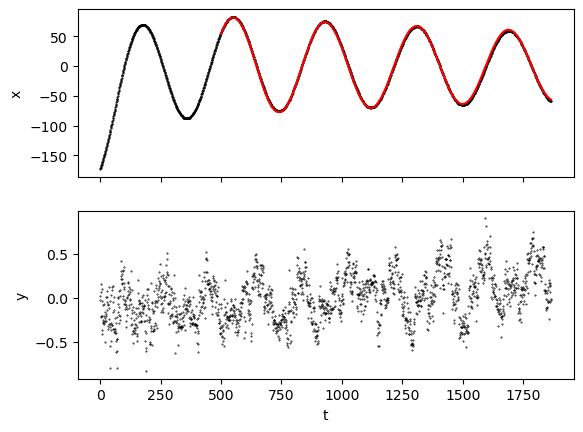

In [180]:
T = ufloat(379.9587037978669, 0) # mean of both, in principle we have zero measurement for full glory
#fit: T0, dtheta1, dtheta2
#theta1=unp.uarray(1042.074833852749, 0 ) #conversion factor for vid setup 1 in cm/'m'. used squared addition here
#theta2=unp.uarray(1249.6597283089984, 0)
theta1 = fit(*np.loadtxt('measurement2/dat_pos1_2.txt', skiprows=2, unpack=True), cutoff=500)[4]
theta2 = fit(*np.loadtxt('measurement2/dat_pos2_2.txt', skiprows=2, unpack=True), cutoff=500)[4]
conversion_factor = 0.0655
print(G(theta1, theta2, T, conversion_factor))